In [1]:
import pandas as pd
import numpy as np

# 🔹 1. Load Data
df = pd.read_csv("calhou.csv")

# 🔹 2. Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# 🔹 3. Encoding (if categorical)
df = pd.get_dummies(df, drop_first=True)

# 🔹 4. Split Features & Target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# 🔹 5. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 6. Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)

In [3]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)  # ✅ no squared
    rmse = np.sqrt(mse)                       # ✅ manual RMSE
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

In [8]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [6]:
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)

    for _ in range(epochs):
        y_pred = X.dot(theta)
        error = y_pred - y
        grad = (1/m) * X.T.dot(error)
        theta -= lr * grad

    return theta

theta = gradient_descent(X_train, y_train.values)
y_pred_gd = X_test.dot(theta)

In [18]:
from sklearn.metrics import mean_squared_error,r2_score

def evaluate(y_test, y_pred):
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

print("OLS:", evaluate(y_test, y_pred_ols))
print("Lasso:", evaluate(y_test, y_pred_lasso))
print("Ridge:", evaluate(y_test, y_pred_ridge))
print("ElasticNet:", evaluate(y_test, y_pred_elastic))
print("Polynomial:", evaluate(y_test, y_pred_poly))
print("Gradient Descent:", evaluate(y_test, y_pred_gd))

OLS: (4904399775.949276, 0.6257351821159705)
Lasso: (4904390870.009304, 0.6257358617465377)
Ridge: (4903987826.868123, 0.6257666187962736)
ElasticNet: (4934103329.050617, 0.6234684429837939)
Polynomial: (4432301282.637223, 0.6617619875752707)
Gradient Descent: (48090198696.2554, -2.6698618137378722)


Accuracy: 0.8425387596899225
Precision: 0.8121677495569994
Recall: 0.8055067369654364


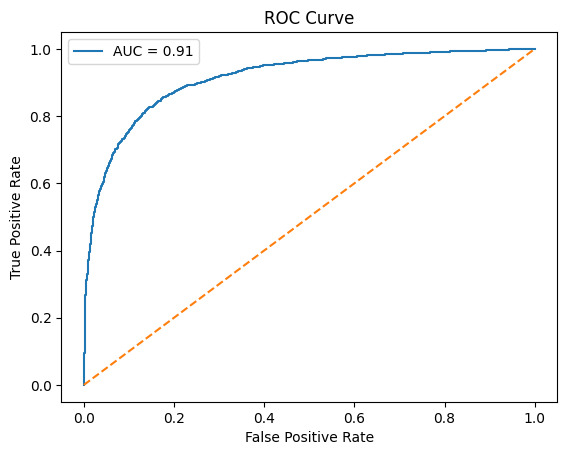

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

# 🔹 Load data
data = pd.read_csv("calhou.csv")

# 🔹 Convert target (FAST way)
y = (data["median_house_value"] > 200000).astype(int)
X = data.drop("median_house_value", axis=1)

# 🔹 Handle categorical data (VERY IMPORTANT)
X = pd.get_dummies(X, drop_first=True)

# Fill missing values with mean
X = X.fillna(X.mean())
# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 Train Model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 🔹 Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

# 🔹 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.6174903100775194
Precision: 0.9383561643835616
Recall: 0.08025776215582894


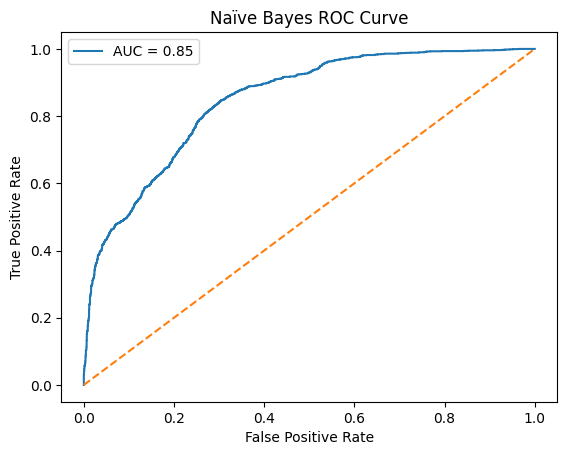

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

# 🔹 Load dataset
data = pd.read_csv("calhou.csv")

# 🔹 Target variable
y = (data["median_house_value"] > 200000).astype(int)
X = data.drop("median_house_value", axis=1)

# 🔹 Handle categorical data (VERY IMPORTANT)
X = pd.get_dummies(X, drop_first=True)

# 🔹 Handle missing values
X = X.fillna(X.mean())

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 Train Model
model = GaussianNB()
model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 🔹 Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

# 🔹 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naïve Bayes ROC Curve")
plt.legend()
plt.show()

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# 🔹 Load dataset
data = pd.read_csv("calhou.csv")

# 🔹 Target
y = (data["median_house_value"] > 200000).astype(int)
X = data.drop("median_house_value", axis=1)

# 🔹 Preprocessing
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean())

# 🔹 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 Models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "Boosting": AdaBoostClassifier(),
    "ID3 (Entropy)": DecisionTreeClassifier(criterion="entropy"),
    "CART (Gini)": DecisionTreeClassifier(criterion="gini"),
    "Stacking": StackingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier()),
            ("rf", RandomForestClassifier())
        ],
        final_estimator=LogisticRegression()
    )
}

# 🔹 Train + Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"\n{name}")
    print("Confusion Matrix:\n", cm)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)


Decision Tree
Confusion Matrix:
 [[2095  326]
 [ 318 1389]]
Accuracy: 0.8439922480620154
Precision: 0.8099125364431486
Recall: 0.8137082601054482

Random Forest
Confusion Matrix:
 [[2201  220]
 [ 243 1464]]
Accuracy: 0.8878391472868217
Precision: 0.8693586698337292
Recall: 0.8576449912126538

Bagging
Confusion Matrix:
 [[2210  211]
 [ 284 1423]]
Accuracy: 0.8800872093023255
Precision: 0.8708690330477357
Recall: 0.833626244874048

Boosting
Confusion Matrix:
 [[2146  275]
 [ 425 1282]]
Accuracy: 0.8304263565891473
Precision: 0.8233782915863841
Recall: 0.7510251903925015

ID3 (Entropy)
Confusion Matrix:
 [[2103  318]
 [ 284 1423]]
Accuracy: 0.8541666666666666
Precision: 0.8173463526708789
Recall: 0.833626244874048

CART (Gini)
Confusion Matrix:
 [[2104  317]
 [ 337 1370]]
Accuracy: 0.8415697674418605
Precision: 0.8120924718435092
Recall: 0.8025776215582894

Stacking
Confusion Matrix:
 [[2185  236]
 [ 235 1472]]
Accuracy: 0.8859011627906976
Precision: 0.8618266978922716
Recall: 0.86233157